In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.shape

(6435, 8)

In [7]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


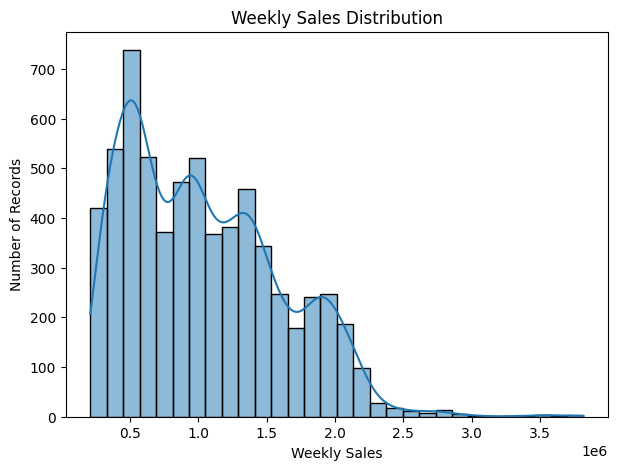

In [14]:
plt.figure(figsize=(7,5))

sns.histplot(df["Weekly_Sales"], bins=30, kde=True)

plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales")
plt.ylabel("Number of Records")

plt.show()

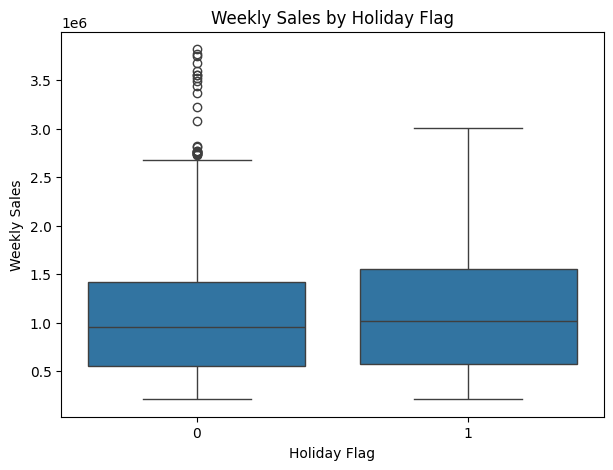

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["Holiday_Flag"], y= df["Weekly_Sales"])
plt.title("Weekly Sales by Holiday Flag")
plt.xlabel("Holiday Flag")
plt.ylabel("Weekly Sales")
plt.show()

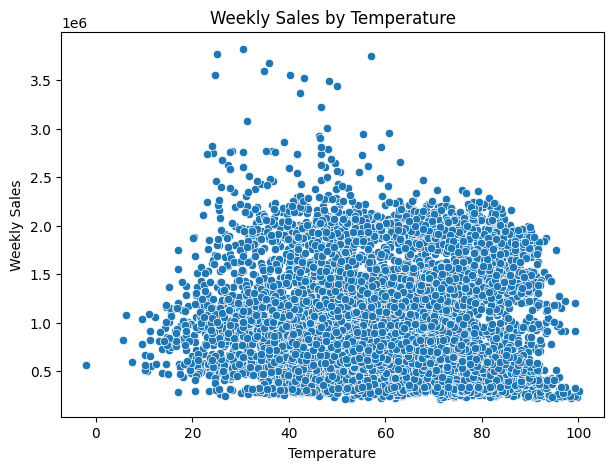

In [16]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df["Temperature"], y= df["Weekly_Sales"])
plt.title("Weekly Sales by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()


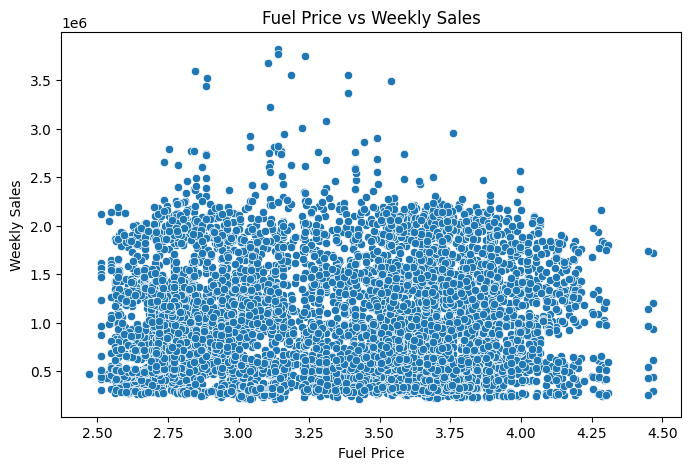

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Fuel_Price", y="Weekly_Sales", data=df)

plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

In [18]:
X = df[['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

y = df['Weekly_Sales']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

LINEAR REGRESSION

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [24]:
model.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [29]:
print(y_pred[:20])

[1196174.80018843 1096306.76027313 1261762.99266103 1102194.4287541
  746743.23493123  924797.90507495  904234.15023466 1206798.699002
 1012720.94896076 1207518.72360719 1215839.96884916 1176779.45218089
 1309259.14679463 1224192.72325389  942723.00844493 1093617.50955308
 1240804.67433864  920760.7829545   899286.44491012 1256251.07197617]


In [30]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
0,1138800.32,1.196175e+06
1,1304850.67,1.096307e+06
2,1769296.25,1.261763e+06
3,1077640.13,1.102194e+06
4,428851.99,7.467432e+05
5,1004523.59,9.247979e+05
6,1523410.71,9.042342e+05
7,1014898.78,1.206799e+06
8,1955896.59,1.012721e+06
9,958667.23,1.207519e+06


In [31]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test, y_pred)

print("R² Score:", accuracy)

R² Score: 0.148063534059508


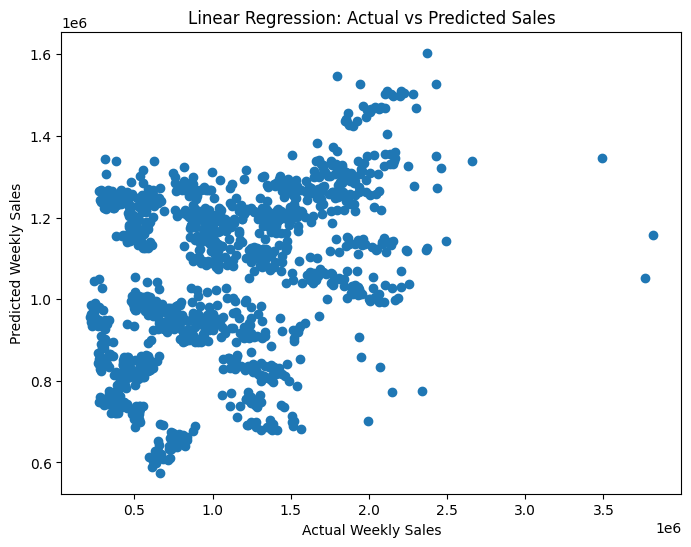

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Linear Regression: Actual vs Predicted Sales")

plt.show()

RANDOM FOREST

In [35]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [36]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [37]:
rf_pred = rf.predict(X_test)

In [38]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Random Forest Prediction": rf_pred
})

comparison.head(10)

,Actual,Random Forest Prediction
0,1138800.32,1.158271e+06
1,1304850.67,1.405650e+06
2,1769296.25,1.846859e+06
3,1077640.13,9.503971e+05
4,428851.99,4.312033e+05
5,1004523.59,9.859199e+05
6,1523410.71,1.203096e+06
7,1014898.78,9.513120e+05
8,1955896.59,2.052877e+06
9,958667.23,9.461184e+05


In [39]:
from sklearn.metrics import r2_score

rf_accuracy = r2_score(y_test, rf_pred)

print("Random Forest R² Score:", rf_accuracy)

Random Forest R² Score: 0.9327096947203809


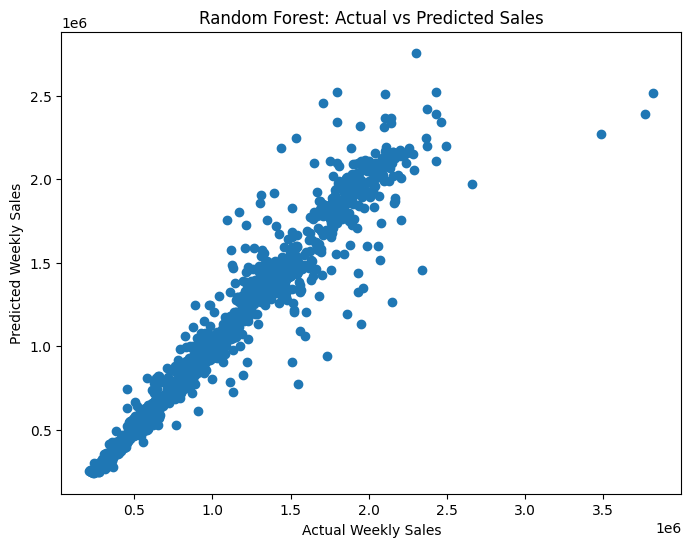

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Random Forest: Actual vs Predicted Sales")

plt.show()

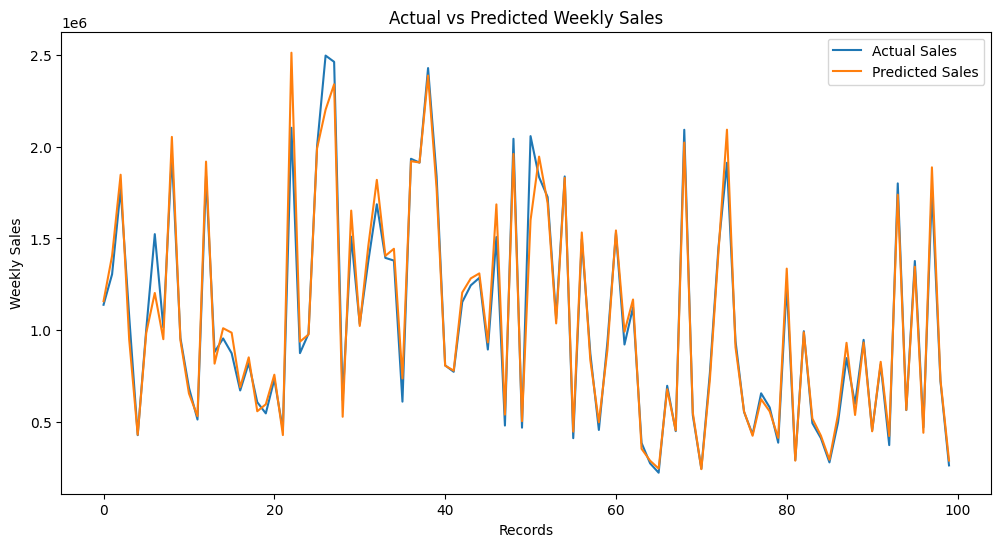

In [42]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual Sales")
plt.plot(rf_pred[:100], label="Predicted Sales")

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Records")
plt.ylabel("Weekly Sales")

plt.legend()

plt.show()

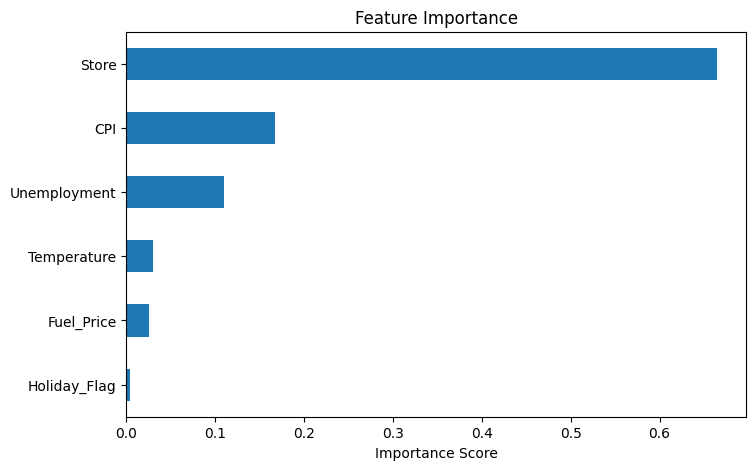

In [43]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure(figsize=(8,5))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()